In [17]:
import numpy as np
import matplotlib.pyplot as plt

# House size in sq ft
X = np.array([
    450, 600, 750, 800, 900, 1000, 1100, 1200, 1250, 1400,
    1500, 1600, 1750, 1800, 1900, 2000, 2200, 2400, 2600, 3000
])

# Price in lakhs (₹)
y = np.array([
    32, 45, 50, 65, 60, 78, 72, 95, 88, 102,
    115, 125, 130, 145, 138, 165, 175, 195, 220, 270
])

learning_rate = 0.01
epochs = 5000

X_scaled = X/1000
lambda_reg = 10

n = len(X_scaled)

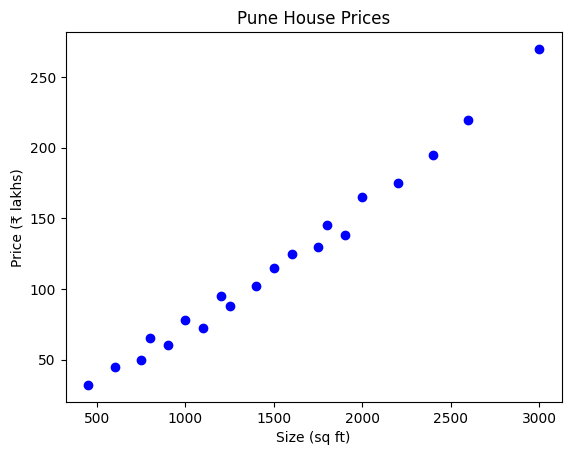

In [18]:
plt.scatter(X, y, color='blue', label='Actual data')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price (₹ lakhs)')
plt.title('Pune House Prices')
plt.show()

In [19]:
w_linear = 0.0
b_linear = 0.0

for epoch in range(epochs):
    y_pred = w_linear * X_scaled + b_linear
    error = y_pred - y
    
    dw = (2/n) * np.sum(error * X_scaled)
    db = (2/n) * np.sum(error)
    
    w_linear -= learning_rate * dw
    b_linear -= learning_rate * db

print(f"Linear:  w = {w_linear:.4f}, b = {b_linear:.4f}")

Linear:  w = 89.5047, b = -16.9021


In [20]:
w_lasso = 0.0
b_lasso = 0.0

for epoch in range(epochs):
        y_pred = w_lasso * X_scaled + b_lasso
    
        error = y_pred - y
    
        dw_lasso = (2/n) * np.sum(error * X_scaled) + lambda_reg * np.sign(w_lasso)
        db_lasso = (2/n) * np.sum(error)
    
        w_lasso = w_lasso - learning_rate * dw_lasso
        b_lasso = b_lasso - learning_rate * db_lasso

print(f"Lasso:   w = {w_lasso:.4f}, b = {b_lasso:.4f}")

Lasso:   w = 78.6681, b = -0.5389


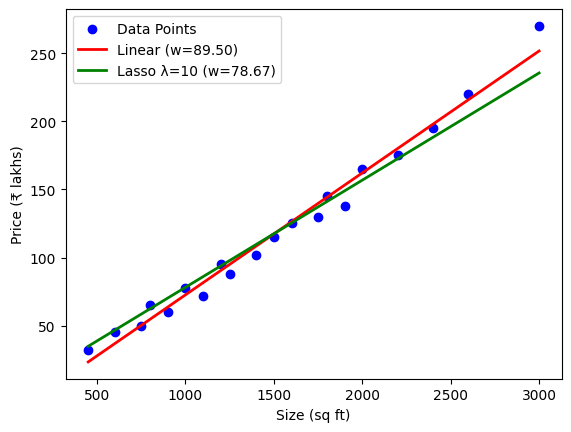

In [21]:
plt.scatter(X, y, color='blue', label='Data Points')

y_linear = w_linear * X_scaled + b_linear
y_lasso = w_lasso * X_scaled + b_lasso

plt.plot(X, y_linear, color='red', linewidth=2, label=f'Linear (w={w_linear:.2f})')
plt.plot(X, y_lasso, color='green', linewidth=2, label=f'Lasso λ={lambda_reg} (w={w_lasso:.2f})')

plt.xlabel('Size (sq ft)')
plt.ylabel('Price (₹ lakhs)')
plt.legend()
plt.show()

In [11]:
print("\n=== Lasso: How weight shrinks with λ ===")
for lam in [0, 0.1, 1, 5, 10, 50, 100]:
    w_test, b_test = 0.0, 0.0
    for epoch in range(5000):
        y_pred = w_test * X_scaled + b_test
        error = y_pred - y
        dw = (2/n) * np.sum(error * X_scaled) + lam * np.sign(w_test)
        db = (2/n) * np.sum(error)
        w_test -= 0.01 * dw
        b_test -= 0.01 * db
    print(f"  λ={lam:>8}: w = {w_test:.4f}, b = {b_test:.4f}")


=== Lasso: How weight shrinks with λ ===
  λ=       0: w = 89.5047, b = -16.9021
  λ=     0.1: w = 89.3963, b = -16.7384
  λ=       1: w = 88.4210, b = -15.2657
  λ=       5: w = 84.0864, b = -8.7205
  λ=      10: w = 78.6681, b = -0.5389
  λ=      50: w = 35.3219, b = 64.9139
  λ=     100: w = 1.1774, b = 116.9632
